In [1]:
import os
import logging
from typing import Dict, Tuple
from pathlib import Path

import numpy as np
import pandas as pd
from nixtla import NixtlaClient
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tqdm import tqdm
from dotenv import load_dotenv

logging.getLogger("nixtla").setLevel(logging.WARNING)
load_dotenv()

True

In [2]:
NIXTLA_API_KEY: str = os.getenv("NIXTLA_API_KEY")
DATA_PATH: Path = Path("commodity_features.csv")
DATE_COL: str = "date"
TARGET_COL: str = "CO1 Comdty"
TRAIN_RATIO: float = 0.90
MODEL_NAME: str = "timegpt-1"  # Zero-shot model
FORECAST_FREQUENCY: str = "D"
FORECAST_HORIZON: int = 1
CONFIDENCE_LEVELS: list[int] = [80, 99]

nixtla_client = NixtlaClient(api_key=NIXTLA_API_KEY)

In [3]:
def load_and_prepare_data(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = df.rename(columns={DATE_COL: "ds", TARGET_COL: "y"})
    df["ds"] = pd.to_datetime(df["ds"], errors="coerce").dt.tz_localize(None)
    df["y"] = pd.to_numeric(df["y"], errors="coerce")

    df = df.resample(FORECAST_FREQUENCY, on="ds").last().reset_index()

    return (
        df[["ds", "y"]]
        .dropna(subset=["ds", "y"])
        .drop_duplicates(subset=["ds"])
        .sort_values("ds")
        .reset_index(drop=True)
    )


raw_data = load_and_prepare_data(DATA_PATH)
raw_data.head()

,ds,y
0,2003-04-11,24.75
1,2003-04-12,24.75
2,2003-04-13,24.75
3,2003-04-14,24.99
4,2003-04-15,25.20


In [4]:
def split_data(
    df: pd.DataFrame, train_ratio: float
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    n_total = len(df)
    n_train = int(n_total * train_ratio)

    train_df = df.iloc[:n_train].copy()
    test_df = df.iloc[n_train:].copy()

    return train_df, test_df


train_data, test_data = split_data(raw_data, TRAIN_RATIO)

assert train_data["ds"].max() < test_data["ds"].min()

print(f"Train shape: {train_data.shape}")
print(f"Test shape: {test_data.shape}")

Train shape: (7290, 2)
Test shape: (811, 2)


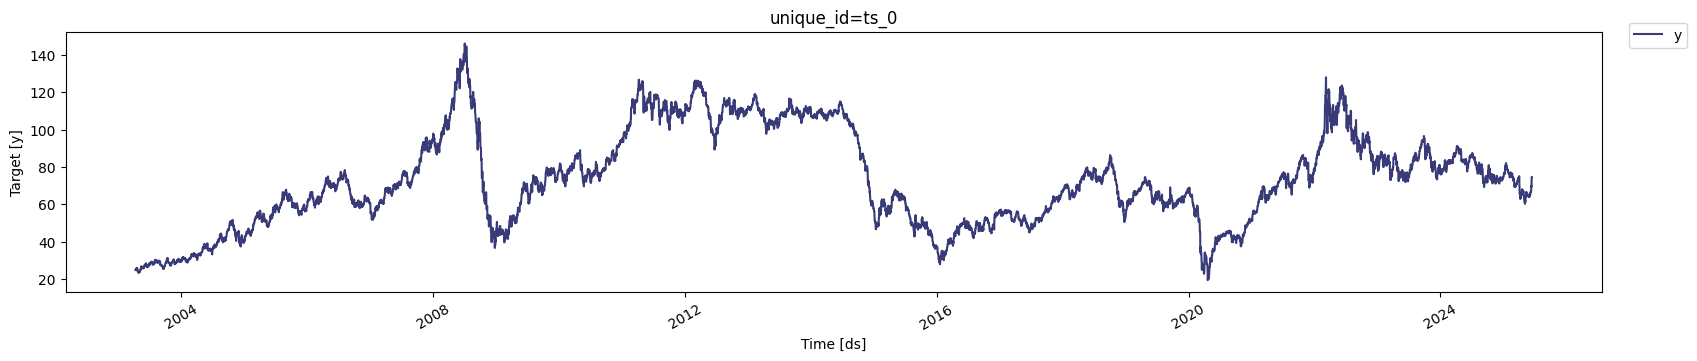

In [5]:
nixtla_client.plot(raw_data)

## Zero-Shot Forecasting
Finetune etmeden aynı train test oranlarıyla modelin kendisiyle tahmin ettirdim.

In [ ]:
def evaluate_forecast(y_true: pd.Series, y_pred: pd.Series) -> Dict[str, float]:
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mask = y_true != 0
    mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask])
    r2 = r2_score(y_true, y_pred)

    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "MAPE": mape, "R2": r2}


def expanding_window_forecast_zero_shot(
    client: NixtlaClient,
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    levels: list[int],
    forecast_horizon: int,
) -> pd.DataFrame:
    predictions = []
    current_train = train_df.copy()

    test_df_len = len(test_df)
    total_steps = (test_df_len + forecast_horizon - 1) // forecast_horizon

    for step in tqdm(range(total_steps), desc="Zero-Shot Expanding Window Forecast"):
        forecast_start = step * forecast_horizon
        forecast_end = min(forecast_start + forecast_horizon, test_df_len)
        current_h = forecast_end - forecast_start

        if current_h <= 0:
            break

        forecast = client.forecast(
            df=current_train,
            h=current_h,
            time_col="ds",
            target_col="y",
            level=levels,
            freq=FORECAST_FREQUENCY,
            model=MODEL_NAME,
        )

        for i in range(current_h):
            pred_idx = forecast_start + i
            if pred_idx < test_df_len:
                pred_data = {
                    "ds": test_df["ds"].iloc[pred_idx],
                    "y": test_df["y"].iloc[pred_idx],
                    "TimeGPT": forecast["TimeGPT"].iloc[i],
                    **{
                        f"TimeGPT-lo-{level}": forecast[f"TimeGPT-lo-{level}"].iloc[i]
                        for level in levels
                    },
                    **{
                        f"TimeGPT-hi-{level}": forecast[f"TimeGPT-hi-{level}"].iloc[i]
                        for level in levels
                    },
                }

                predictions.append(pred_data)

        if forecast_start < test_df_len:
            new_observations = test_df.iloc[:forecast_end][["ds", "y"]].copy()
            current_train = pd.concat(
                [current_train, new_observations], ignore_index=True
            )
            current_train = current_train.drop_duplicates(subset=["ds"]).sort_values(
                "ds"
            )

    return pd.DataFrame(predictions)


test_results_zero_shot = expanding_window_forecast_zero_shot(
    client=nixtla_client,
    train_df=train_data,
    test_df=test_data,
    levels=CONFIDENCE_LEVELS,
    forecast_horizon=FORECAST_HORIZON,
)

test_metrics_zero_shot = evaluate_forecast(
    test_results_zero_shot["y"], test_results_zero_shot["TimeGPT"]
)

print(f"\nZero-Shot Test Metrics:")
for k, v in test_metrics_zero_shot.items():
    print(f"{k}: {v:.4f}")

Zero-Shot Expanding Window Forecast: 100%|██████████| 811/811 [11:33<00:00,  1.17it/s]


Zero-Shot Test Metrics:
MAE: 0.9459
MSE: 1.7841
RMSE: 1.3357
MAPE: 0.0122
R2: 0.9638


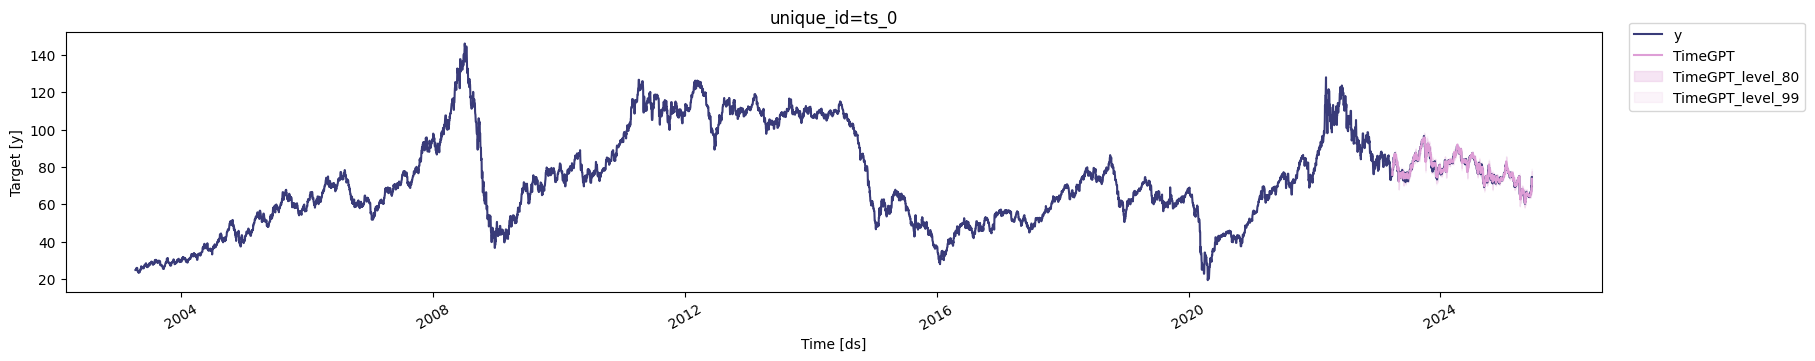

In [7]:
nixtla_client.plot(train_data, test_results_zero_shot, level=CONFIDENCE_LEVELS)

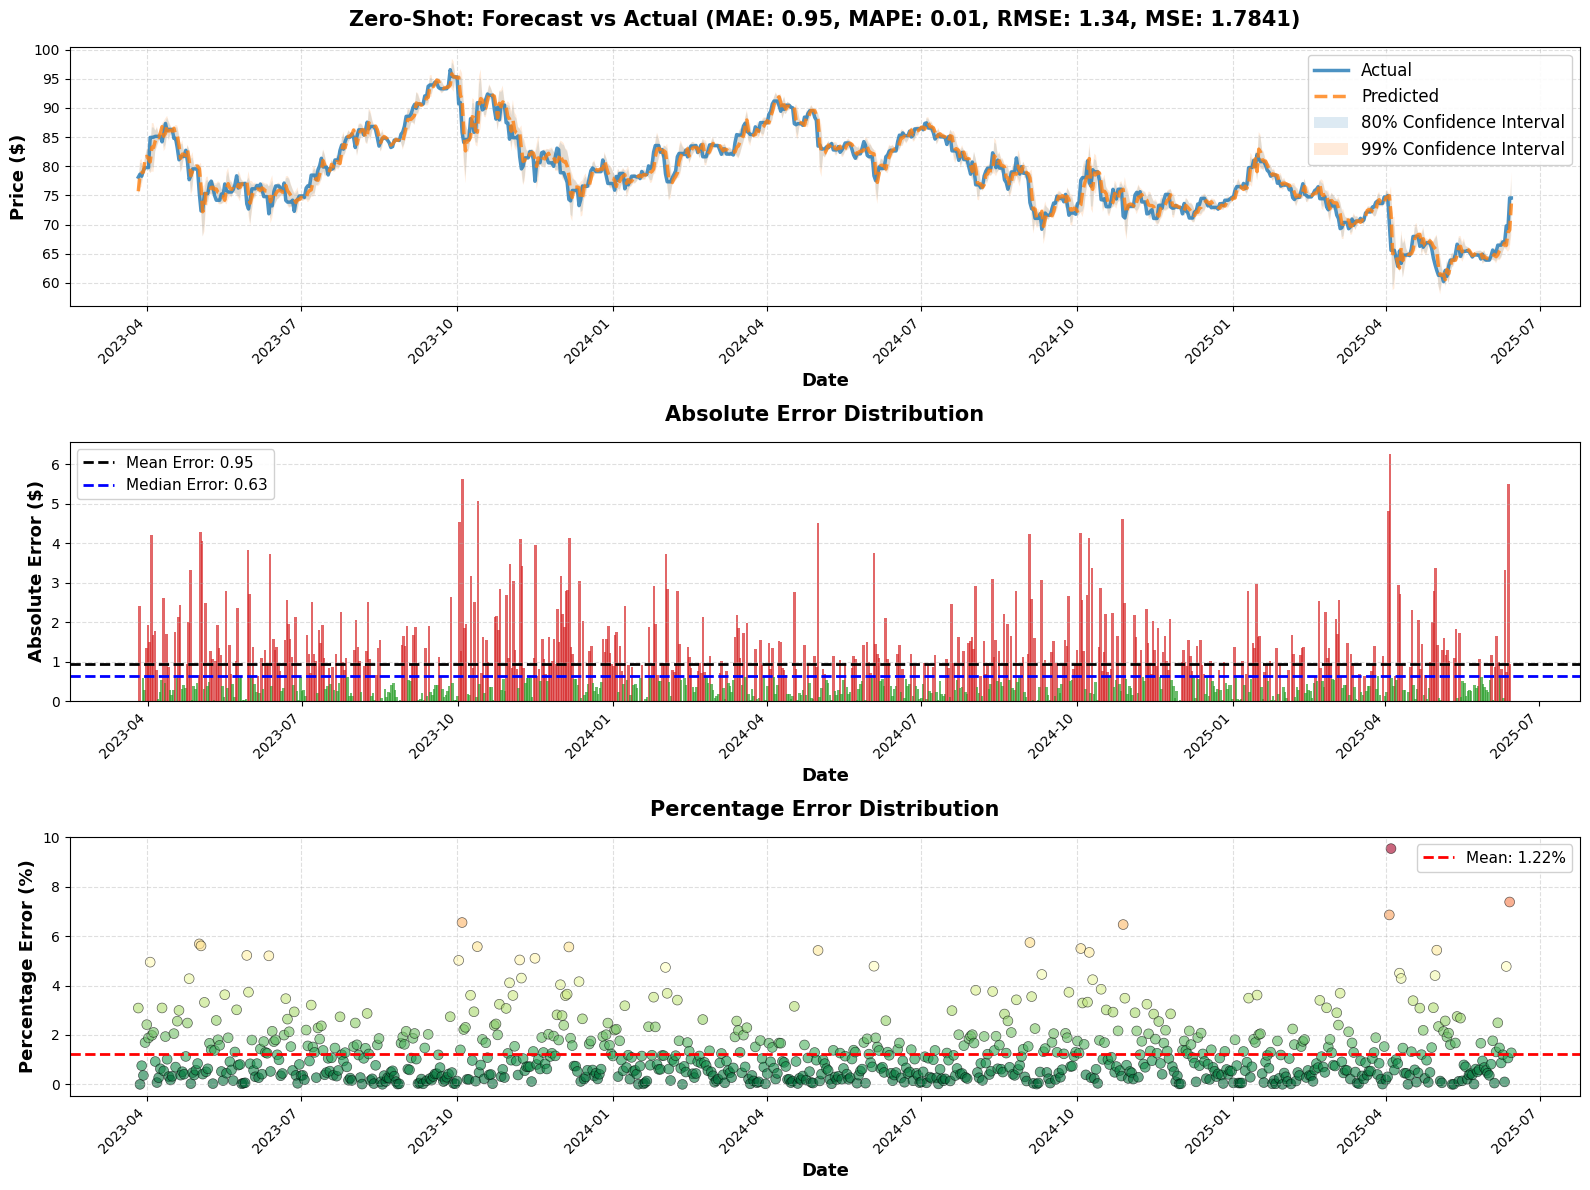

In [8]:
def visualize_forecast_results(
    results_df: pd.DataFrame,
    metrics: Dict[str, float],
    confidence_levels: list[int],
    figsize: Tuple[int, int] = (16, 12),
    title_prefix: str = "",
) -> None:
    fig, axes = plt.subplots(3, 1, figsize=figsize)

    ax_forecast = axes[0]
    ax_forecast.plot(
        results_df["ds"],
        results_df["y"],
        label="Actual",
        color="#1f77b4",
        linewidth=2.5,
        alpha=0.8,
    )
    ax_forecast.plot(
        results_df["ds"],
        results_df["TimeGPT"],
        label="Predicted",
        color="#ff7f0e",
        linewidth=2.5,
        alpha=0.8,
        linestyle="--",
    )

    for level in confidence_levels:
        ax_forecast.fill_between(
            results_df["ds"],
            results_df[f"TimeGPT-lo-{level}"],
            results_df[f"TimeGPT-hi-{level}"],
            alpha=0.15,
            label=f"{level}% Confidence Interval",
        )

    ax_forecast.set_xlabel("Date", fontsize=13, fontweight="bold")
    ax_forecast.set_ylabel("Price ($)", fontsize=13, fontweight="bold")
    ax_forecast.set_title(
        f"{title_prefix}Forecast vs Actual (MAE: {metrics['MAE']:.2f}, MAPE: {metrics['MAPE']:.2f}, RMSE: {metrics['RMSE']:.2f}, MSE: {metrics['MSE']:.4f})",
        fontsize=15,
        fontweight="bold",
        pad=15,
    )
    ax_forecast.legend(fontsize=12, loc="best", framealpha=0.9)
    ax_forecast.grid(True, alpha=0.4, linestyle="--")
    ax_forecast.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax_forecast.xaxis.get_majorticklabels(), rotation=45, ha="right")

    ax_abs_error = axes[1]
    absolute_error = np.abs(results_df["y"] - results_df["TimeGPT"])
    median_error = absolute_error.median()
    colors = ["#2ca02c" if err < median_error else "#d62728" for err in absolute_error]
    ax_abs_error.bar(
        results_df["ds"],
        absolute_error,
        color=colors,
        alpha=0.7,
        width=1.5,
    )
    ax_abs_error.axhline(
        absolute_error.mean(),
        color="black",
        linestyle="--",
        linewidth=2,
        label=f"Mean Error: {absolute_error.mean():.2f}",
    )
    ax_abs_error.axhline(
        median_error,
        color="blue",
        linestyle="--",
        linewidth=2,
        label=f"Median Error: {median_error:.2f}",
    )
    ax_abs_error.set_xlabel("Date", fontsize=13, fontweight="bold")
    ax_abs_error.set_ylabel("Absolute Error ($)", fontsize=13, fontweight="bold")
    ax_abs_error.set_title(
        "Absolute Error Distribution", fontsize=15, fontweight="bold", pad=15
    )
    ax_abs_error.legend(fontsize=11, loc="best", framealpha=0.9)
    ax_abs_error.grid(True, alpha=0.4, axis="y", linestyle="--")
    ax_abs_error.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax_abs_error.xaxis.get_majorticklabels(), rotation=45, ha="right")

    ax_pct_error = axes[2]
    percentage_error = 100 * absolute_error / results_df["y"]
    ax_pct_error.scatter(
        results_df["ds"],
        percentage_error,
        c=percentage_error,
        cmap="RdYlGn_r",
        s=50,
        alpha=0.6,
        edgecolors="black",
        linewidth=0.5,
    )
    ax_pct_error.axhline(
        percentage_error.mean(),
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean: {percentage_error.mean():.2f}%",
    )
    ax_pct_error.set_xlabel("Date", fontsize=13, fontweight="bold")
    ax_pct_error.set_ylabel("Percentage Error (%)", fontsize=13, fontweight="bold")
    ax_pct_error.set_title(
        "Percentage Error Distribution", fontsize=15, fontweight="bold", pad=15
    )
    ax_pct_error.legend(fontsize=11, loc="best", framealpha=0.9)
    ax_pct_error.grid(True, alpha=0.4, linestyle="--")
    ax_pct_error.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax_pct_error.xaxis.get_majorticklabels(), rotation=45, ha="right")

    plt.tight_layout()
    plt.show()


visualize_forecast_results(
    test_results_zero_shot,
    test_metrics_zero_shot,
    CONFIDENCE_LEVELS,
    title_prefix="Zero-Shot: ",
)

In [9]:
def display_summary_statistics(
    results_df: pd.DataFrame, metrics: Dict[str, float], confidence_levels: list[int]
) -> None:
    print("=" * 70)
    print("ZERO-SHOT TEST SET SUMMARY STATISTICS")
    print("=" * 70)
    print(f"Total Predictions: {len(results_df)}")
    print(
        f"Date Range: {results_df['ds'].min().date()} to {results_df['ds'].max().date()}"
    )

    print(f"\nPerformance Metrics:")
    print(f"  MAE:  {metrics['MAE']:.4f} $")
    print(f"  MSE:  {metrics['MSE']:.4f} $²")
    print(f"  RMSE: {metrics['RMSE']:.4f} $")
    print(f"  MAPE: {metrics['MAPE']*100:.2f}%")

    absolute_error = np.abs(results_df["y"] - results_df["TimeGPT"])
    print(f"\nError Distribution:")
    print(f"  Min Error:        {absolute_error.min():.4f} $")
    print(f"  Max Error:        {absolute_error.max():.4f} $")
    print(f"  Mean Error:       {absolute_error.mean():.4f} $")
    print(f"  Median Error:     {absolute_error.median():.4f} $")
    print(f"  Std Dev:          {absolute_error.std():.4f} $")
    print(f"  Error Skewness:   {absolute_error.skew():.4f}")

    print(f"\nPrice Statistics:")
    print(f"  Actual Mean:      {results_df['y'].mean():.2f} $")
    print(f"  Predicted Mean:   {results_df['TimeGPT'].mean():.2f} $")
    print(
        f"  Mean Bias:        {(results_df['TimeGPT'] - results_df['y']).mean():.4f} $"
    )
    print(f"  Actual Min:       {results_df['y'].min():.2f} $")
    print(f"  Actual Max:       {results_df['y'].max():.2f} $")
    print(f"  Price Range:      {results_df['y'].max() - results_df['y'].min():.2f} $")

    print(f"\nConfidence Interval Coverage:")
    for level in confidence_levels:
        within_interval = (
            (results_df["y"] >= results_df[f"TimeGPT-lo-{level}"])
            & (results_df["y"] <= results_df[f"TimeGPT-hi-{level}"])
        ).sum()
        coverage = (within_interval / len(results_df)) * 100
        avg_width = (
            results_df[f"TimeGPT-hi-{level}"] - results_df[f"TimeGPT-lo-{level}"]
        ).mean()
        expected_coverage = level
        coverage_diff = coverage - expected_coverage
        print(
            f"  {level}% Level: {coverage:.1f}% coverage (expected: {expected_coverage}%, diff: {coverage_diff:+.1f}%)"
        )
        print(f"              Average interval width: ${avg_width:.2f}")

    print("=" * 70)


display_summary_statistics(
    test_results_zero_shot, test_metrics_zero_shot, CONFIDENCE_LEVELS
)

ZERO-SHOT TEST SET SUMMARY STATISTICS
Total Predictions: 811
Date Range: 2023-03-27 to 2025-06-14

Performance Metrics:
  MAE:  0.9459 $
  MSE:  1.7841 $²
  RMSE: 1.3357 $
  MAPE: 1.22%

Error Distribution:
  Min Error:        0.0001 $
  Max Error:        6.2549 $
  Mean Error:       0.9459 $
  Median Error:     0.6320 $
  Std Dev:          0.9436 $
  Error Skewness:   1.8891

Price Statistics:
  Actual Mean:      78.81 $
  Predicted Mean:   78.93 $
  Mean Bias:        0.1209 $
  Actual Min:       60.23 $
  Actual Max:       96.55 $
  Price Range:      36.32 $

Confidence Interval Coverage:
  80% Level: 60.8% coverage (expected: 80%, diff: -19.2%)
              Average interval width: $2.21
  99% Level: 67.3% coverage (expected: 99%, diff: -31.7%)
              Average interval width: $2.67
